(qr-section)=

# QR decomposition

QR decomposition is another decomposition method that factorises a matrix in the product of an orthogonal matrix $Q$ and an upper triangular matrix $R$ such that

$$ \begin{align*}
    A = QR.
\end{align*} $$

QR decomposition is particularly useful for solving least-squares problems and computing eigenvalues. Unlike LU decomposition, QR decomposition can be applied to rectangular matrices and is numerically more stable.

````{prf:definition} Orthogonal vectors
:label: orthogonal-vector-definition

A set of vectors $\{ \mathbf{v}_1 ,\mathbf{v}_2 ,\mathbf{v}_3 ,\dots \}$ is said to be **orthogonal** if $\mathbf{v}_i \cdot \mathbf{v}_j =0$ for $i\not= j$. Furthermore the set is said to be **orthonormal** if $\mathbf{v}_i$ are unit vectors.
````

````{prf:definition} Orthogonal matrix
:label: orthogonal-matrix-definition

An **orthogonal matrix** is a matrix whose columns form an orthonormal set. Equivalently

$$ \begin{align*}
    A^\mathsf{T} A = AA^\mathsf{T} = I.
\end{align*} $$
````

For example consider the matrix

$$ \begin{align*}
    A= \begin{pmatrix}
        0.8 & -0.6\\
        0.6 & 0.8
    \end{pmatrix}.
\end{align*} $$

This is an orthogonal matrix since

$$ \begin{align*}
    A^\mathsf{T} A=\begin{pmatrix}
        0.8 & 0.6\\
        -0.6 & 0.8
    \end{pmatrix}
    \begin{pmatrix}
        0.8 & -0.6\\
        0.6 & 0.8
    \end{pmatrix} = 
    \begin{pmatrix}
        1 & 0\\
        0 & 1
    \end{pmatrix}=I.
\end{align*} $$

---

(qr-gramschmidt-section)=

## QR decomposition using the Gram-Schmidt process

Consider the $3 \times 3$ matrix $A$ represented as the concatenation of the column vectors $\mathbf{a}_1, \mathbf{a}_2, \mathbf{a}_3$

$$ \begin{pmatrix}
    a_{11} & a_{12} & a_{13} \\
    a_{21} & a_{22} & a_{23} \\
    a_{31} & a_{32} & a_{33}
\end{pmatrix} =
\begin{pmatrix}
    \uparrow & \uparrow & \uparrow \\
    \mathbf{a}_1 & \mathbf{a}_2 & \mathbf{a}_3 \\
    \downarrow & \downarrow & \downarrow
\end{pmatrix} $$

where $\mathbf{a}_j = (a_{1j}, a_{2j}, a_{3j})$. To calculate the orthogonal $Q$ matrix we need a set of vectors $\{\mathbf{q}_1, \mathbf{q}_2, \mathbf{q}_3\}$ that span the same space as $\{\mathbf{a}_1, \mathbf{a}_2, \mathbf{a}_3\}$ but are orthogonal to each other. One way to do this is using the **Gram-Schmidt process**. Consider the diagram shown in {numref}`gram-schmidt-figure` that shows the first two non-orthogonal vectors $\mathbf{a}_1$ and $\mathbf{a}_2$. 

```{figure} ../_images/gram_schmidt.svg
:name: gram-schmidt-figure
:width: 400

The Gram-Schmidt process
```

We begin by letting $\mathbf{u}_1 = \mathbf{a}_1$ and seek to find a vector $\mathbf{u}_2$ that is orthogonal to $\mathbf{u}_1$ and in the same span as $\mathbf{a}_2$. To do this we subtract the <a href="https://en.wikipedia.org/wiki/Vector_projection" target="_blank">vector projection</a> of $\mathbf{a}_2$ onto $\mathbf{u}_1$, i.e.,

$$ \mathbf{u}_2 = \mathbf{a}_2 - \left( \frac{\mathbf{u}_1 \cdot \mathbf{a}_1}{\mathbf{u}_1 \cdot \mathbf{u}_1} \right) \mathbf{u}_1.$$

We can simplify things by normalising $\mathbf{u}_1$ such that $\mathbf{q}_1 = \dfrac{\mathbf{u}_1}{\|\mathbf{u}_1\|}$ so we have

$$ \mathbf{u}_2 = \mathbf{a}_2 - (\mathbf{q}_1 \cdot \mathbf{a}_2) \mathbf{q}_1, $$(gramschmidt-u2-equation)

which we also normalise to give $\mathbf{q}_2 = \dfrac{\mathbf{u}_2}{\|\mathbf{u}_2\|}$. For the next vector $\mathbf{a}_3$ we want the vector $\mathbf{u}_3$ to be orthogonal to both $\mathbf{q}_1$ and $\mathbf{q}_2$ so we subtract both the vector projections of $\mathbf{a}_3$ onto $\mathbf{q}_1$ and $\mathbf{q}_2$

$$ \mathbf{u}_3 = \mathbf{a}_3 - (\mathbf{q}_1 \cdot \mathbf{a}_3) \mathbf{q}_1 - (\mathbf{q}_2 \cdot \mathbf{a}_3) \mathbf{q}_2, $$(gramschmidt-u3-equation)

which is normalised to give $\mathbf{q}_3$. Using $\mathbf{u}_i = (\mathbf{q}_i \cdot \mathbf{a}_i) \mathbf{q}_i$ and rearranging {eq}`gramschmidt-u2-equation` and {eq}`gramschmidt-u3-equation` to make $\mathbf{a}_i$ the subject and 

$$ \begin{align*}
  \mathbf{a}_1 &= (\mathbf{q}_1 \cdot \mathbf{a}_1) \mathbf{q}_1, \\
  \mathbf{a}_2 &= (\mathbf{q}_1 \cdot \mathbf{a}_2) \mathbf{q}_1 + (\mathbf{q}_2 \cdot \mathbf{a}_2) \mathbf{q}_2, \\
  \mathbf{a}_3 &= (\mathbf{q}_1 \cdot \mathbf{a}_3) \mathbf{q}_1 + (\mathbf{q}_2 \cdot \mathbf{a}_3) \mathbf{q}_2 + (\mathbf{q}_3 \cdot \mathbf{a}_3) \mathbf{q}_3, \\
  & \vdots 
\end{align*} $$

The columns of the $Q$ matrix are formed using the vectors $\mathbf{q}_i$ 

$$ Q = 
\begin{pmatrix}
    \uparrow & \uparrow & & \uparrow \\
    \mathbf{q}_1 & \mathbf{q}_2 & \cdots & \mathbf{q}_n \\
    \downarrow & \downarrow & & \downarrow
\end{pmatrix}, $$

and the elements of the $R$ matrix are formed from the dot products of the $\mathbf{q}_i$ and $\mathbf{a}_j$ vectors such that

$$ R = \begin{pmatrix}
  (\mathbf{q}_1 \cdot \mathbf{a}_1) & (\mathbf{q}_1 \cdot \mathbf{a}_2) & \cdots & (\mathbf{q}_1 \cdot \mathbf{a}_n) \\
  0 & (\mathbf{q}_2 \cdot \mathbf{a}_2) & \cdots & (\mathbf{q}_2 \cdot \mathbf{a}_n) \\
  \vdots & \ddots & \ddots & \vdots \\
  0 & \cdots & 0 & (\mathbf{q}_n \cdot \mathbf{a}_n)
\end{pmatrix}. $$

### Positive diagonal elements of $R$

It has become standard convention to impose a condition that the diagonal elements of $R$ must be positive so that we get a unique factorisation. Consider $A = QR$ then multiplying a column of $Q$ by $-1$ and the corresponding row of $R$ by $-1$ doesn't change the product $QR$. So if any of the diagonal elements of $R$ are negative we multiply the corresponding column of $Q$ and row of $R$ by $-1$.

  
```{prf:algorithm} QR decomposition using the Gram-Schmidt process
:label: qr-gramschmidt-algorithm

**Inputs:** An $m \times n$ matrix $A$.

**Outputs:** An $m \times n$ orthogonal matrix $Q$ and and $n \times n$ upper triangular matrix $R$ such that $A = QR$.

- For $j = 1, \ldots, n$ do
  - $r_{ij} \gets \mathbf{q}_i \cdot \mathbf{a}_j, \qquad i = 1, \ldots, j - 1$ 
  - $\mathbf{u}_j \gets \mathbf{a}_j - \displaystyle\sum_{i=1}^{j-1} r_{ij} \mathbf{q}_i$
  - $r_{jj} \gets \| \mathbf{u}_j \|$
  - $\mathbf{q}_j \gets \dfrac{\mathbf{u}_j}{r_{jj}}$
- $Q \gets (\mathbf{q}_1, \mathbf{q}_2, \ldots, \mathbf{q}_n)$

- For $i = 1, \ldots, n$ do
  - If $r_{ii} < 0$ then
    - $R(i,: ) \gets -R(i,:)$
    - $Q(:,i) \gets -Q(:,i)$

- Return $Q$ and $R$
```
 
```{prf:example}
:label: qr-gramschmidt-example

Calculate the QR decomposition of the following matrix using the Gram-Schmidt process

$$ \begin{align*}
    A  = \begin{pmatrix}
        -1 & -1 & 1 \\
        1 & 3 & 3 \\
        -1 & -1 & 5 \\
        1 & 3 & 7
    \end{pmatrix}.
\end{align*} $$

---

**Solution**


$$ \begin{align*}
  j &= 1: & \mathbf{u}_1 &= \mathbf{a}_1 = \begin{pmatrix} -1 \\ 1 \\ -1 \\ 1 \end{pmatrix}, \\
  && r_{11} &= \| \mathbf{u}_1 \| = 2, \\
  && \mathbf{q}_1 &= \frac{\mathbf{u}_1}{r_{11}} = \frac{1}{2} \begin{pmatrix} -1 \\ 1 \\ 1 \\ 1 \end{pmatrix} = \begin{pmatrix} -\frac{1}{2} \\ \frac{1}{2} \\ -\frac{1}{2} \\ \frac{1}{2} \end{pmatrix}. \\
  j &= 2: & r_{12} &= \mathbf{q}_1 \cdot \mathbf{a}_2 = 
  \begin{pmatrix} -\frac{1}{2} \\ \frac{1}{2} \\ -\frac{1}{2} \\ \frac{1}{2} \end{pmatrix} \cdot \begin{pmatrix} -1 \\ 3 \\ -1 \\ 3 \end{pmatrix} = 4, \\
  && \mathbf{u}_2 &= \mathbf{a}_2 - r_{12} \mathbf{q}_1 = 
  \begin{pmatrix} -1 \\ 3 \\ -1 \\ 3 \end{pmatrix} - 4 
  \begin{pmatrix} -\frac{1}{2} \\ \frac{1}{2} \\ -\frac{1}{2} \\ \frac{1}{2} \end{pmatrix} = 
  \begin{pmatrix} 1 \\ 1 \\ 1 \\ 1 \end{pmatrix}, \\
  && r_{22} &= \| \mathbf{u}_2 \| = 2, \\
  && \mathbf{q}_2 &= \frac{\mathbf{u}_2}{r_{22}} = \frac{1}{2}
  \begin{pmatrix} 1 \\ 1 \\ 1 \\ 1 \end{pmatrix} = 
  \begin{pmatrix} \frac{1}{2} \\ \frac{1}{2} \\ \frac{1}{2} \\ \frac{1}{2} \end{pmatrix}. \\
  j &= 3: & r_{13} &= \mathbf{q}_1 \cdot \mathbf{a}_3 = 
  \begin{pmatrix} -\frac{1}{2} \\ \frac{1}{2} \\ -\frac{1}{2} \\ \frac{1}{2} \end{pmatrix} \cdot
  \begin{pmatrix} 1 \\ 3\\ 5 \\ 7 \end{pmatrix} = 2, \\
  && r_{23} &= \mathbf{q}_2 \cdot \mathbf{a}_3 = 
  \begin{pmatrix} \frac{1}{2} \\ \frac{1}{2} \\ \frac{1}{2} \\ \frac{1}{2} \end{pmatrix} \cdot
  \begin{pmatrix} 1 \\ 3 \\ 5 \\ 7 \end{pmatrix} = 8, \\
  && \mathbf{u}_3 &= \mathbf{a}_3 - r_{13} \mathbf{q}_1 - r_{23} \mathbf{q}_2 =
  \begin{pmatrix} 1 \\ 3 \\ 5 \\ 7 \end{pmatrix} - 2
  \begin{pmatrix} -\frac{1}{2} \\ \frac{1}{2} \\ -\frac{1}{2} \\ \frac{1}{2} \end{pmatrix} - 8
  \begin{pmatrix} \frac{1}{2} \\ \frac{1}{2} \\ \frac{1}{2} \\ \frac{1}{2} \end{pmatrix} = 
  \begin{pmatrix} -2 \\ -2 \\ 2 \\ 2 \end{pmatrix}, \\
  && r_{33} &= \| \mathbf{u}_3 \| = 4, \\
  && \mathbf{q}_3 &= \frac{\mathbf{u}_3}{r_{33}} = \frac{1}{4} 
  \begin{pmatrix} -2 \\ -2 \\ 2 \\ 2 \end{pmatrix} =
  \begin{pmatrix} -\frac{1}{2} \\ -\frac{1}{2} \\ \frac{1}{2} \\ \frac{1}{2} \end{pmatrix}. 
\end{align*} $$

The diagonal elements of $R$ are all positive so we don't need to make any adjustments. Thus the $Q$ and $R$ matrices are given by

$$ \begin{align*}
  Q &= \begin{pmatrix}
    -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\
    \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\
    -\frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\
    \frac{1}{2} & \frac{1}{2} & \frac{1}{2}
  \end{pmatrix}, &
  R &= 
  \begin{pmatrix}
    2 & 4 & 2 \\
    0 & 2 & 8 \\
    0 & 0 & 4
  \end{pmatrix}.
\end{align*} $$

We can check that this is correct by verifying that $A = QR$ and that $Q^\mathsf{T}Q = I$.

$$ \begin{align*}
  \begin{pmatrix}
    -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\
    \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\
    -\frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\
    \frac{1}{2} & \frac{1}{2} & \frac{1}{2}
  \end{pmatrix}
  \begin{pmatrix}
    2 & 4 & 2 \\
    0 & 2 & 8 \\
    0 & 0 & 4
  \end{pmatrix} &=
  \begin{pmatrix}
    -1 & -1 & 1 \\
    1 & 3 & 3 \\
    -1 & -1 & 5 \\
    1 & 3 & 7
  \end{pmatrix} = A, \\
  \begin{pmatrix}
    -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} \\
    \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\
    -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & \frac{1}{2}
  \end{pmatrix}
  \begin{pmatrix}
    -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\
    \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\
    -\frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\
    \frac{1}{2} & \frac{1}{2} & \frac{1}{2}
  \end{pmatrix} &=
  \begin{pmatrix}
    1 & 0 & 0 \\
    0 & 1 & 0 \\
    0 & 0 & 1
  \end{pmatrix} = I.
\end{align*} $$
```
(qr-householder-section)=

## QR decomposition using Householder reflections

Another method we can use to calculate the QR decomposition of a matrix is by the use of **Householder reflections**. 

```{prf:definition} Householder matrix

The Householder matrix is an orthogonal reflection matrix of the form

$$ H = I - 2 \frac{\mathbf{v} \mathbf{v}^\mathsf{T}}{\mathbf{v}^\mathsf{T} \mathbf{v}}, $$(householder-equation)

where $\mathbf{v}$ is a non-zero column vector. The matrix $H$ is symmetric and orthogonal.
```

```{figure} ../_images/householder_1.svg
:name: householder-1-figure
:width: 350

The vector $\mathbf{x}$ is reflected about the hyperplane normal to the vector $\mathbf{v}$ so that it is parallel to the basis vector $\mathbf{e}_1$.
```

Consider the diagram in {numref}`householder-1-figure` where the vector $\mathbf{x}$ is reflected about the hyperplane so that it is parallel to the first basis vector of the standard basis $\mathbf{e}_1 = (1, 0, \ldots, 0)^\mathsf{T}$. The Householder matrix that achieves this reflection is written in terms of the vector $\mathbf{v}$ which is normal to the reflecting hyperplane

$$ \mathbf{v} = \mathbf{x} - \|\mathbf{x}\|\mathbf{e}_1. $$

If the magnitude of $\mathbf{x}$ is close to being parallel to $\mathbf{e}_1$ then $\mathbf{v}$ will be close to $\mathbf{0}$ and the calculation of {eq}`householder-equation` will involve the division by a number close to zero. To overcome this we use a Householder transformation to reflect $\mathbf{x}$ so that it is parallel to $-\mathbf{e}_1$ instead of $+\mathbf{e}_1$. 

```{figure} ../_images/householder_2.svg
:name: householder-2-figure
:width: 450

The vector $\mathbf{x}$ is reflected about the dashed line so that it is parallel to the basis vector $-\mathbf{e}_1$.
```

To do this we calculate $\mathbf{v}$ by adding $\| \mathbf{x} \| \mathbf{e}_1$ to $ \mathbf{x}$ when the sign of $x_1$ is negative, i.e.,

$$ \mathbf{v} = \mathbf{x} - \operatorname{sign}(x_1) \| \mathbf{x} \| \mathbf{e}_1, $$

where $\operatorname{sign}(x)$ returns $+1$ if $x \geq 0$ and $-1$ if $x < 0$. To compute the QR decomposition of a matrix $A$, we reflect the first column of $A$, using Householder reflection so that it is parallel to $\mathbf{e}_1$. This means that $r_{11}$ is the only non-zero element in the first column of $R$.

$$ \begin{align*}
  R = H_1 A = 
  \begin{pmatrix}
    r_{11} & r_{12} & r_{13} & \cdots & r_{1n} \\
    0 & b_{22} & b_{23} & \cdots & b_{2n} \\
    0 & b_{32} & b_{33} & \cdots & b_{3n} \\
    \vdots & \vdots & \vdots & \ddots & \vdots \\
    0 & b_{m2} & b_{m3} & \cdots & b_{mn}
  \end{pmatrix}
\end{align*} $$

We then look to do the same for the sub-matrix of $R$ formed by omitted its first row and column. We do this by calculating a $(m-1) \times (m-1)$ Householder matrix $H'$ using the second column of $R$ starting from the diagonal element, i.e., $\mathbf{x} = (b_{22}, b_{32}, \ldots, b_{m2})^\mathsf{T}$. This is used to form the $m \times m$ Householder matrix $H_2$ by padding out the first row and column of the identity matrix.

$$ \begin{align*}
  H_2 = \begin{pmatrix} 
    1 & \begin{matrix} 0 & \cdots & 0 \end{matrix} \\
    \begin{matrix} 0 \\ \vdots \\ 0 \end{matrix} & H'
  \end{pmatrix}
\end{align*} $$

The Householder matrix $H_2$ is then applied to $R$ so that the elements of the second column below the diagonal are zeroed out. 

$$ \begin{align*}
  R = H_2 R = 
  \begin{pmatrix}
    r_{11} & r_{12} & r_{13} & \cdots & r_{1n} \\
    0 & r_{22} & r_{23} & \cdots & r_{2n} \\
    0 & 0 & c_{33} &\cdots & c_{3n} \\
    \vdots & \vdots & \vdots & \ddots & \vdots \\
    0 & 0 & c_{n3} & \cdots & c_{nn}
  \end{pmatrix}
\end{align*} $$

We repeat this process until column $j = m - 1$ when $R$ will be an upper triangular matrix. If $A$ has $n$ columns then 

$$R = H_{m-1}\ldots H_2 H_1 A,$$

rearranging gives

$$\begin{align*}
  H_1^{-1} H_2^{-1} \ldots H_{m-1}^{-1} R = A.
\end{align*} $$

The Householder matrices are symmetric and orthogonal so $H^{-1} = H$ and since we want $A = QR$ then

$$ \begin{align*}
  Q = H_1H_2 \ldots H_{m-1}.
\end{align*} $$

Since each Householder matrix is orthogonal, their product is also orthogonal. Therefore $Q$ is automatically orthogonal.

```{prf:algorithm} QR decomposition using Householder reflections
:label: qr-householder-algorithm

**Inputs:** An $m \times n$ matrix $A$.

**Outputs:** An $n \times n$ orthogonal matrix $Q$ and and $n \times n$ upper triangular matrix $R$ such that $A = QR$.

- $Q \gets I_m$
- $R \gets A$
- for $j = 1, \ldots, \min(m - 1, n)$
  - $\mathbf{x} \gets$ column $j$ of $R$ starting at the $j$-th row
  - $\mathbf{v} \gets \mathbf{x} - \operatorname{sign} (x_1) \|\mathbf{x}\|\mathbf{e}_1$
  - $H' \gets I_{m-j+1} - 2 \dfrac{\mathbf{v} \mathbf{v} ^\mathsf{T}}{\mathbf{v}^\mathsf{T} \mathbf{v}}$
  - $H(j:m, j:m) \gets H'$ with the first $j-1$ rows and columns of $H$ set to those of $I_m$
  - $R \gets H R$
  - $Q \gets Q H$
  
- for $i = 1, \ldots, n$ do
  - If $R(i,i) < 0$ then
    - $R(i,: ) \gets -R(i,:)$
    - $Q(:,i) \gets -Q(:,i)$

- Return $Q$ and $R$.
```

```{prf:example}
:label: qr-householder-example

Calculate the QR decomposition of the following matrix using Householder reflections

$$ \begin{align*}
  A=\begin{pmatrix}
    1 & -4 \\
    2 & 3 \\
    2 & 2
  \end{pmatrix}.
\end{align*} $$

---

**Solution**

Set $Q = I$ and $R = A$. We want to zero out the elements below $R(1,1)$ so $\mathbf{x} = (1, 2, 2)^\mathsf{T}$ and $\|\mathbf{x}\| = 3$.

$$ \begin{align*}
  j &= 1: & \mathbf{x} &= 
  \begin{pmatrix} 1 \\ 2 \\ 2 \end{pmatrix}, \\
  && \mathbf{v} &= \mathbf{x} - \operatorname{sign}(x_1) \|\mathbf{x}\| \mathbf{e}_1 = 
  \begin{pmatrix} 1 \\ 2 \\ 2 \end{pmatrix} - 3 
  \begin{pmatrix} 1 \\ 0 \\ 0 \end{pmatrix} = 
  \begin{pmatrix} -2 \\ 2 \\ 2 \end{pmatrix}, \\
  && H &= I - 2 \frac{\mathbf{v} \mathbf{v}^\mathsf{T}}{\mathbf{v}^\mathsf{T} \mathbf{v}} = 
  \begin{pmatrix} 
    1 & 0 & 0 \\ 
    0 & 1 & 0 \\ 
    0 & 0 & 1 
  \end{pmatrix} - \frac{2}{12}
  \begin{pmatrix} 
    4 & -4 & -4 \\
    -4 & 4 & 4 \\
    -4 & 4 & 4
  \end{pmatrix} =
  \begin{pmatrix} 
    \frac{1}{3} & \frac{2}{3} & \frac{2}{3} \\ 
    \frac{2}{3} & \frac{1}{3} & -\frac{2}{3} \\ 
    \frac{2}{3} & -\frac{2}{3} & \frac{1}{3} 
  \end{pmatrix}, \\
  && R &= H R =
  \begin{pmatrix} 
    \frac{1}{3} & \frac{2}{3} & \frac{2}{3} \\ 
    \frac{2}{3} & \frac{1}{3} & -\frac{2}{3} \\ 
    \frac{2}{3} & -\frac{2}{3} & \frac{1}{3} 
  \end{pmatrix}
  \begin{pmatrix}
    1 & -4 \\
    2 & 3 \\
    2 & 2
  \end{pmatrix} =
  \begin{pmatrix} 
    3 & 2 \\ 
    0 & -3 \\ 
    0 & -4
  \end{pmatrix}, \\
  && Q &= QH =
  \begin{pmatrix} 
    1 & 0 & 0 \\ 
    0 & 1 & 0 \\ 
    0 & 0 & 1 
  \end{pmatrix}
  \begin{pmatrix} 
    \frac{1}{3} & \frac{2}{3} & \frac{2}{3} \\ 
    \frac{2}{3} & \frac{1}{3} & -\frac{2}{3} \\ 
    \frac{2}{3} & -\frac{2}{3} & \frac{1}{3} 
  \end{pmatrix} =
  \begin{pmatrix} 
    \frac{1}{3} & \frac{2}{3} & \frac{2}{3} \\ 
    \frac{2}{3} & \frac{1}{3} & -\frac{2}{3} \\ 
    \frac{2}{3} & -\frac{2}{3} & \frac{1}{3} 
  \end{pmatrix}. \\
  j &= 2: & \mathbf{x} &= 
  \begin{pmatrix} -3 \\ -4 \end{pmatrix}, \\
  && \mathbf{v} &= \mathbf{x} - \operatorname{sign}(x_1) \|\mathbf{x}\| \mathbf{e}_1 = 
  \begin{pmatrix} -3 \\ -4 \end{pmatrix} + 5 
  \begin{pmatrix} 1 \\ 0 \end{pmatrix} = 
  \begin{pmatrix} 2 \\ -4 \end{pmatrix}, \\
  && H' &= I - 2 \frac{\mathbf{v}\mathbf{v}^\mathsf{T}}{\mathbf{v}^\mathsf{T} \mathbf{v}} =
  \begin{pmatrix} 
    1 & 0 \\ 
    0 & 1 
  \end{pmatrix} - \frac{2}{20}
  \begin{pmatrix} 
    4 & -8 \\ 
    -8 & 16 
  \end{pmatrix} =
  \begin{pmatrix} 
    \frac{3}{5} & \frac{4}{5} \\ 
    \frac{4}{5} & -\frac{3}{5} 
  \end{pmatrix}, \\
  && H &=
  \begin{pmatrix} 
    1 & 0 & 0 \\ 
    0 & \frac{3}{5} & \frac{4}{5} \\ 
    0 & \frac{4}{5} & -\frac{3}{5}
  \end{pmatrix}, \\
  && R &= H R =
  \begin{pmatrix} 
    1 & 0 & 0 \\ 
    0 & -\frac{3}{5} & -\frac{4}{5} \\ 
    0 & -\frac{4}{5} & \frac{3}{5}
  \end{pmatrix}
  \begin{pmatrix} 
    3 & 2 \\ 
    0 & 3 \\ 
    0 & -4
  \end{pmatrix} =
  \begin{pmatrix} 
    3 & 2 \\ 
    0 & -5 \\ 
    0 & 0
  \end{pmatrix}, \\
  && Q &= Q H =
  \begin{pmatrix} 
    \frac{1}{3} & \frac{2}{3} & \frac{2}{3} \\ 
    \frac{2}{3} & \frac{2}{3} & -\frac{1}{3} \\ 
    \frac{2}{3} & -\frac{1}{3} & \frac{2}{3} 
  \end{pmatrix}
  \begin{pmatrix} 
    1 & 0 & 0 \\ 
    0 & \frac{3}{5} & \frac{4}{5} \\ 
    0 & \frac{4}{5} & -\frac{3}{5}
  \end{pmatrix} =
  \begin{pmatrix} 
    \frac{1}{3} & \frac{14}{15} & \frac{2}{15} \\ 
    \frac{2}{3} & -\frac{1}{3} & \frac{2}{3} \\ 
    \frac{2}{3} & -\frac{2}{15} & -\frac{11}{15} 
  \end{pmatrix}.
\end{align*} $$

The second diagonal element of $R$ is negative, so we multiply row 2 of $R$ and column 2 of $Q$ by $-1$

$$ \begin{align*}
  Q &= 
  \begin{pmatrix} 
    \frac{1}{3} & -\frac{14}{15} & \frac{2}{15} \\ 
    \frac{2}{3} &  \frac{1}{3} & \frac{2}{3} \\ 
    \frac{2}{3} & \frac{2}{15} & -\frac{11}{15} 
  \end{pmatrix}, &
  R &= 
  \begin{pmatrix} 
    3 & 2 \\ 
    0 & 5 \\ 
    0 & 0
  \end{pmatrix}.
\end{align*} $$

We can check whether this is correct by verifying that $A = QR$ and $Q^\mathsf{T} Q = I$.

$$ \begin{align*}
  QR &= 
  \begin{pmatrix} 
    \frac{1}{3} & -\frac{14}{15} & \frac{2}{15} \\ 
    \frac{2}{3} &  \frac{1}{3} & \frac{2}{3} \\ 
    \frac{2}{3} & \frac{2}{15} & -\frac{11}{15} 
  \end{pmatrix}
  \begin{pmatrix} 
    3 & 2 \\ 
    0 & 5 \\ 
    0 & 0
  \end{pmatrix} =
  \begin{pmatrix}
    1 & -4 \\
    2 & 3 \\
    2 & 2
  \end{pmatrix} = A, \\
  Q^\mathsf{T} Q &= 
  \begin{pmatrix} 
    \frac{1}{3} & \frac{2}{3} & \frac{2}{3} \\
    -\frac{14}{15} & \frac{1}{3} & \frac{2}{15} \\
    \frac{2}{15} & \frac{2}{3} & -\frac{11}{15}
  \end{pmatrix}
  \begin{pmatrix} 
    \frac{1}{3} & -\frac{14}{15} & \frac{2}{15} \\ 
    \frac{2}{3} &  \frac{1}{3} & \frac{2}{3} \\ 
    \frac{2}{3} & \frac{2}{15} & -\frac{11}{15} 
  \end{pmatrix} =
  \begin{pmatrix}
    1 & 0 & 0 \\
    0 & 1 & 0 \\
    0 & 0 & 1
  \end{pmatrix} = I.
\end{align*} $$
```

---

## Loss of orthogonality

Like any numerical technique, the QR decomposition methods shown here are prone to computational rounding errors. If $Q$ is perfectly orthogonal then $Q^\mathsf{T}Q = I$, but if there is bound to be some small error, i.e.,

$$ Q^\mathsf{T}Q = I + E $$

where $E$ is the orthogonality error matrix. A single value for the loss of orthogonality can be computed using

$$ \| E \|_F = \| Q^\mathsf{T}Q - I \|_F, $$

where $\| \cdot \|_F$ is the Frobenius norm defined by

$$ \| A \|_F = \sqrt{ \displaystyle\sum_{i=1}^m \displaystyle\sum_{j=1}^n |a_{ij}|^2}. $$

The both QR decomposition methods shown here use an iterative approach where we orthogonalised the columns of the $A$ matrix in turn based upon the previous iterations. So an error in column $i$ will have a knock on effect on all subsequent columns. To analyse the methods, the QR decomposition of a random $200 \times 200$ matrix $A$ was computed using the Gram-Schmidt process and Householder reflections. The Frobenius norm was calculated for the first $n$ columns of $Q$ where $n = 1 \ldots 200$ giving the loss of orthogonality for those iterations and plotted in below.

```{glue:figure} loss-of-orthogonality-plot

Comparisons between the loss of orthogonality using Gram-Schmidt and Householder reflections to compute the QR decomposition of a 200 column matrix.
```

The loss of orthogonality grows much more slowly for Householder reflections than for classical Gram-Schmidt. For this reason, Householder QR is the method used in most numerical linear algebra software.
(eigenvalues-using-qr-decomposition-section)=

# Calculating eigenvalues using QR decomposition

<a href="https://en.wikipedia.org/wiki/Eigenvalues_and_eigenvectors" target="_blank">Eigenvalues and eigenvectors</a> feature prominently in the study of numerical methods for ODEs. Given a system of ODEs, the eigenvalues of the coefficient matrix provide information about the stability, divergence, oscillatory behavior, and constant solutions of the system. 

```{prf:definition} Eigenvalue
:label: eigenvalue-definition

Let $A$ be an $n \times n$ matrix. A scalar $\lambda$ is an **eigenvalue** of $A$ if there exists a non-zero vector $\mathbf{v}$ such that 

$$A \mathbf{v} = \lambda \mathbf{v}.$$(eigenvalue-definition-equation)

The vector $\mathbf{v}$ is called the **eigenvector** associated with the eigenvalue $\lambda$.
```

Rearranging equation {eq}`eigenvalue-definition-equation` we have

$$ \begin{align*}
    A \mathbf{v} &= \lambda \mathbf{v} \\
    (A - \lambda I) \mathbf{v} &= \mathbf{0}.
\end{align*} $$

Since $\mathbf{v} \ne \mathbf{0}$, the homogeneous system $(A - \lambda I) \mathbf{v} = \mathbf{0}$ has non-trivial solution. This occurs if and only if $A - \lambda I$ is singular, which means

$$ \det(A - \lambda I) = 0.$$(eigenvalue-determinant-formula-equation)

For example, consider the eigenvalues of the matrix

$$ A = \begin{pmatrix} 2 & 1 \\ 2 & 3 \end{pmatrix}.$$

Using equation {eq}`eigenvalue-determinant-formula-equation`

$$ \begin{align*}
    \det \begin{pmatrix} 2 - \lambda & 1 \\ 2 & 3 - \lambda \end{pmatrix} &= 0 \\
    \lambda^2 - 5 \lambda + 4 &= 0 \\
    (\lambda - 1)(\lambda - 4) &= 0
\end{align*} $$

so the eigenvalues are $\lambda_1 = 4$ and $\lambda_2 = 1$ [^1]. The problem with using determinants to calculate eigenvalues is that it is too computationally expensive for larger matrices.

[^1]: Eigenvalues are usually listed in descending order by their absolute values.

---

## The QR algorithm

Although the characteristic polynomial can be used to determine eigenvalues analytically for small matrices, it becomes computationally expensive and numerically unreliable for large matrices. Modern numerical software therefore uses iterative methods such as the QR algorithm.

The **QR algorithm** is a method of computing the eigenvalues of a square matrix $A$. Let 

$$ A_0 = A, $$ 

and for $k = 0, 1, \ldots, $

$$ \begin{align*}
    A_k &= Q_k R_k,\\
    A_{k+1} &= R_k Q_k.
\end{align*} $$

Since $Q_k$ is orthogonal then $Q^{-1} = Q^T$ and

$$ A_{k+1} = R_kQ_k = Q_k^{-1} (Q_kR_k) Q_k = Q^{-1}A_kQ_k = Q_k^\mathrm{T}A_kQ_k. $$

Since 

$$ A_{k+1} = Q_k^\mathsf{T} A_k Q_k, $$

each iterate is similar to the previous iterate. Therefore all matrices $A_0, A_1, A_2, \ldots $ have exactly the same eigenvalues. Under suitable conidtions, $A_k$ converges to an upper triangular matrix.

$$ A_{k \to \infty} =
\begin{pmatrix}
    \lambda_1 & \star & \cdots & \star \\
    0 & \lambda_2 & \ddots & \vdots \\
    \vdots & \ddots & \ddots & \star \\
    0 & \cdots & 0 & \lambda_n 
\end{pmatrix}. $$

```{prf:theorem} QR algorithm

Let $A_0 = A$ and suppose

$$ A_k = Q_kR_k, $$

is the QR decomposition of $A_k$. Define

$$ A_{k+1} = R_kQ_k. $$

Then

$$ A_{k+1} = Q_k^\mathsf{T} A_k Q_k, $$

so $A_{k+1}$ is similar to $A_k$ and therefore has the same eigenvalues.
```

```{prf:algorithm} The QR algorithm
:label: qr-algorithm

**Inputs:** An $n \times n$ matrix $A$ and an accuracy tolerance $tol$.

**Outputs:** A vector $(\lambda_1, \lambda_2, \ldots, \lambda_n)$ containing the eigenvalues of $A$.

- for $k = 1, 2, \ldots$
  - Calculate the QR decomposition of $A$
  - $A \gets R Q$
  - If $\max(|a_{ij}| \text{ for } i > j) < tol$
    - Break
- Return $\operatorname{diag}(A)$
```

```{prf:example}
:label: qr-algorithm-example

Use the QR algorithm to compute the eigenvalues of the matrix

$$ A = \begin{pmatrix} 1 & 2 \\ 3 & 4 \end{pmatrix}, $$

using an accuracy tolerance of $tol = 10^{-4}$. 

---

**Solution**

Calculate the QR decomposition of $A_0$

$$ \begin{align*}
    Q_0 &= \begin{pmatrix} 
         0.3162 & 0.9487 \\ 
         0.9487 & -0.3162 
    \end{pmatrix}, \\
    R_0 &= \begin{pmatrix} 
        3.1623 & 4.4272 \\
        0 & 0.6325
    \end{pmatrix}
\end{align*} $$

and calculate $A_1 = R_0Q_0$

$$ \begin{align*}
    A_1 &= 
    \begin{pmatrix} 
        3.1623 & 4.4272 \\
        0 & 0.6325
    \end{pmatrix}
    \begin{pmatrix} 
        0.3162 & 0.9487 \\ 
        0.9487 & -0.3162 
    \end{pmatrix} \\
    &=
    \begin{pmatrix}
        5.2 & 1.6 \\
        0.6 & -0.2 
    \end{pmatrix}
\end{align*} $$

Calculate the QR decomposition of $A_1$

$$ \begin{align*}
    Q_1 &=
    \begin{pmatrix}
        0.9943 & 0.1146 \\
        0.1146 & -0.9934
    \end{pmatrix}, \\
    R_1 &= 
    \begin{pmatrix}
        5.2345 & 1.5665 \\
        0 & 0.3821
    \end{pmatrix}
\end{align*} $$

and calculate $A_2 = R_1Q_1$

$$ \begin{align*}
    A_2 &=
    \begin{pmatrix}
        5.2345 & 1.5665 \\
        0 & 0.3821
    \end{pmatrix}
    \begin{pmatrix}
        0.9943 & 0.1146 \\
        0.1146 & -0.9934
    \end{pmatrix} \\
    &=
    \begin{pmatrix}
        5.3796 & -0.9562 \\
        0.0438 & -0.3796
    \end{pmatrix}.
\end{align*} $$

Continuing the iteration gives the sequence of diagonal estimates shown below.

| $k$  | $\lambda_1$ | $\lambda_2$  | $\max(\|a_{ij}\|, i > j)$  |
|:---:|:-------:|:---------:|:--------:|
| 0  | 1.000000 | 4.000000 | 3.000000 |
| 1  | 5.200000 | -0.200000 | 0.600000 |
| 2  | 5.379562 | -0.379562 | 0.043796 |
| 3  | 5.371753 | -0.371753 | 0.003026 |
| 4  | 5.372318 | -0.372318 | 0.000210 |
| 5  | 5.372279 | -0.372279 | 0.000015 |

Using the characteristic polynomial to compute the actual eigenvalues

$$ \begin{align*}
    \det \begin{pmatrix} 1 - \lambda & 2 \\ 3 & 4 - \lambda \end{pmatrix} = \lambda^2 - 5 \lambda - 2,
\end{align*} $$


so $\lambda_1 = (5 + \sqrt{33})/2 \approx 5.372281$ and $\lambda_2 = (5 - \sqrt{33}) / 2 \approx -0.372281$ which shows the QR algorithm has calculated the eigenvalues correct to four decimal places.
```

In [1]:
import numpy as np

def qr_gramschmidt(A):
    m, n = A.shape
    Q, R = np.copy(A).astype(float), np.zeros((n,n))
    for j in range(n):
        for i in range(j):
            R[i,j] = np.dot(Q[:,i], A[:,j])
            Q[:,j] = Q[:,j] - R[i,j] * Q[:,i]
        
        R[j,j] = np.linalg.norm(Q[:,j])
        Q[:,j] = Q[:,j] / R[j,j]

    for i in range(n):
        for j in range(i):
            if R[j,j] < 0:
                R[j,:] *= -1
                Q[:,j] *= -1

    return Q, R

# Define matrix
A = np.array([[-1, -1, 1], 
              [1, 3, 3], 
              [-1, -1, 5], 
              [1, 3, 7]])

# Calculate QR decomposition
Q, R = qr_gramschmidt(A)
print(f"Q = \n{Q}\n\nR = \n{R}")

Q = 
[[-0.5  0.5 -0.5]
 [ 0.5  0.5 -0.5]
 [-0.5  0.5  0.5]
 [ 0.5  0.5  0.5]]

R = 
[[2. 4. 2.]
 [0. 2. 8.]
 [0. 0. 4.]]


In [2]:
import numpy as np

def qr_householder(A):
    
    m, n = A.shape
    Q, R = np.eye(m), np.copy(A).astype(float)

    for i in range(m - 1):
        x = R[i:,i]
        v = np.array([x - np.sign(x[0]) *  np.linalg.norm(x) * np.eye(m - i)[:,0]]).T
        H = np.eye(m)
        H[i:,i:] -= 2 * np.dot(v, v.T) / np.dot(v.T, v)
        R = np.dot(H, R)
        Q = np.dot(Q, H)

    for i in range(n):
        if R[i,i] < 0:
            R[i,:] *= -1
            Q[:,i] *= -1

    return Q, R

# Define matrix
A = np.array([[1, -4],
              [2, 3],
              [2, 2]])

# Calculate QR decomposition
Q, R = qr_householder(A)
print("Q = \n", Q)
print("R = \n", R)
print("QR = \n", np.dot(Q, R))


Q = 
 [[ 0.33333333 -0.93333333  0.13333333]
 [ 0.66666667  0.33333333  0.66666667]
 [ 0.66666667  0.13333333 -0.73333333]]
R = 
 [[ 3.00000000e+00  2.00000000e+00]
 [-2.22044605e-16  5.00000000e+00]
 [ 1.11022302e-16 -8.88178420e-17]]
QR = 
 [[ 1. -4.]
 [ 2.  3.]
 [ 2.  2.]]


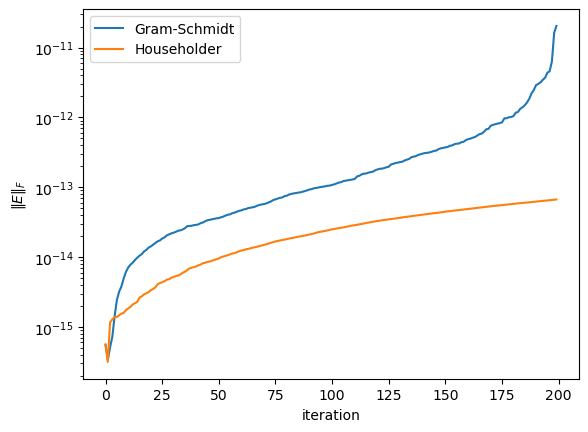

In [9]:
import matplotlib.pyplot as plt

def orthogonality_loss(Q):
    n = Q.shape[1]
    return np.linalg.norm(np.dot(Q.T, Q) - np.eye(n))

sizes = range(1, 201)
loss_gs, loss_hh = [], []
# sizes = range(4, 1001)
np.random.seed(0)
A = np.random.rand(sizes[-1], sizes[-1])
Q1, R1 = qr_gramschmidt(A)
Q2, R2 = qr_householder(A)
for n in sizes:
    loss_gs.append(orthogonality_loss(Q1[:,:n]))
    loss_hh.append(orthogonality_loss(Q2[:,:n]))


fig, ax = plt.subplots()
plt.semilogy(loss_gs, label='Gram-Schmidt')
plt.semilogy(loss_hh, label='Householder')
plt.legend()
plt.xlabel('iteration')
plt.ylabel('$\\| E \\|_F$')

from myst_nb import glue
glue("loss-of-orthogonality-plot", fig, display=False)

In [ ]:
import numpy as np

def qr_householder(A):
    
    m, n = A.shape
    Q, R = np.eye(m), np.copy(A)

    for i in range(m - 1):
        x = R[i:,i]
        v = np.array([x - np.linalg.norm(x) * np.eye(m - i)[:,0]]).T
        H = np.eye(m)
        H[i:,i:] -= 2 * np.dot(v, v.T) / np.dot(v.T, v)
        R = np.dot(H, R)
        Q = np.dot(Q, H)

    for i in range(n):
        if R[i,i] < 0:
            R[i,:] = -R[i,:]
            Q[:,i] = -Q[:,i]

    return Q, R


A = np.array([[1, 2], [3, 4]])

Q, R = qr_householder(A)
print("Q =\n", Q)
print("R =\n", R)

A = R @ Q
print("A1 =\n", A)

Q, R = qr_householder(A)
print("Q =\n", Q)
print("R =\n", R)

A = R @ Q
print("A2 =\n", A)

print(f"diff = {np.max(abs(np.tril(A, -1))):0.4f}")

Q =
 [[ 0.31622777  0.9486833 ]
 [ 0.9486833  -0.31622777]]
R =
 [[3.16227766e+00 4.42718872e+00]
 [4.44089210e-16 6.32455532e-01]]
A1 =
 [[ 5.2  1.6]
 [ 0.6 -0.2]]
Q =
 [[ 0.99340894  0.11462411]
 [ 0.11462411 -0.99340894]]
R =
 [[5.23450093e+00 1.56652948e+00]
 [3.15106627e-16 3.82080360e-01]]
A2 =
 [[ 5.37956204 -0.95620438]
 [ 0.04379562 -0.37956204]]
diff = 0.0438


In [10]:
def eigvals(A, tol=1e-6):

    print("| n  | lambda_1 | lambda_2  | max(aij, i > j) |")
    print("|:---:|:-------:|:---------:|:--------:|")
    print(f"| {0}  | {A[0,0]:0.6f} | {A[1,1]:0.6f} | {abs(A[1,0]):0.6f} |")

    for k in range(20):
        Q, R = qr_householder(A)
        A = R @ Q

        print(f"| {k+1}  | {A[0,0]:0.6f} | {A[1,1]:0.6f} | {abs(A[1,0]):0.6f} |")

        if np.max(abs(np.tril(A, -1))) < tol:
            break

    return np.diagonal(A)


# # Define matrix
A = np.array([[1, 2],
              [3, 4]])

# Calculate eigenvalues
lambda_ = eigvals(A, 1e-4)

| n  | lambda_1 | lambda_2  | max(aij, i > j) |
|:---:|:-------:|:---------:|:--------:|
| 0  | 1.000000 | 4.000000 | 3.000000 |
| 1  | 5.200000 | -0.200000 | 0.600000 |
| 2  | 5.379562 | -0.379562 | 0.043796 |
| 3  | 5.371753 | -0.371753 | 0.003026 |
| 4  | 5.372318 | -0.372318 | 0.000210 |
| 5  | 5.372279 | -0.372279 | 0.000015 |
